# classml demo

A quick tour of the estimators in `classml`, all implemented from scratch in NumPy and checked against scikit-learn. Data comes from sklearn toy loaders only, so this notebook runs fully offline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

from classml import PCA, GaussianMixtureEM, KernelSVM, KMeans, LogisticRegression

## Logistic regression vs RBF kernel SVM on two moons

The logistic model can only draw a linear boundary, the RBF SVM can bend around the moons.

logistic regression accuracy: 0.8700
RBF kernel SVM accuracy     : 0.9667


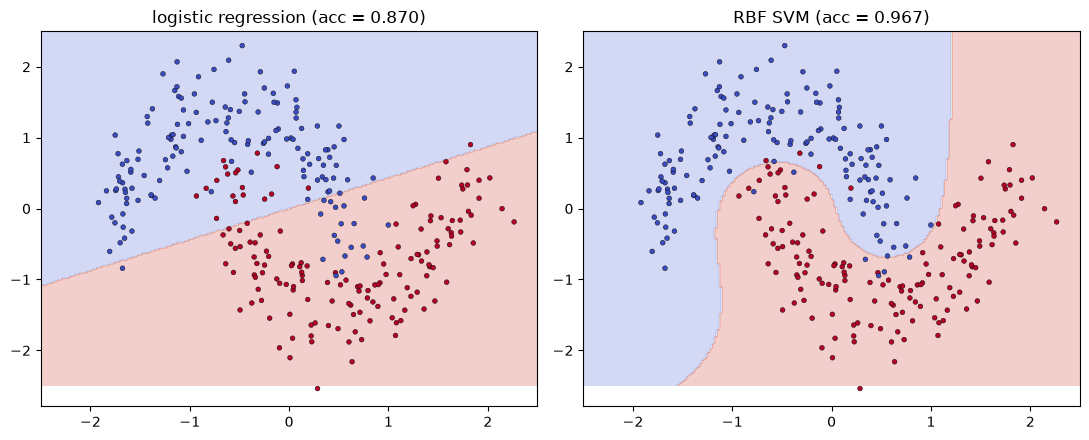

In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=7)
X = StandardScaler().fit_transform(X)

logreg = LogisticRegression(learning_rate=0.5, n_iter=5000).fit(X, y)
svm = KernelSVM(C=1.0, gamma=1.0, random_state=0).fit(X, y)
print(f"logistic regression accuracy: {logreg.score(X, y):.4f}")
print(f"RBF kernel SVM accuracy     : {svm.score(X, y):.4f}")

xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model, title in [(axes[0], logreg, "logistic regression"), (axes[1], svm, "RBF SVM")]:
    zz = model.predict(grid).reshape(xx.shape).astype(float)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12, edgecolors="k", linewidths=0.3)
    ax.set_title(f"{title} (acc = {model.score(X, y):.3f})")
plt.tight_layout()
plt.show()

## K-means and Gaussian mixture EM on blobs

k-means inertia: 1724.18
GMM converged in 20 EM iterations, mean log-likelihood -4.2900


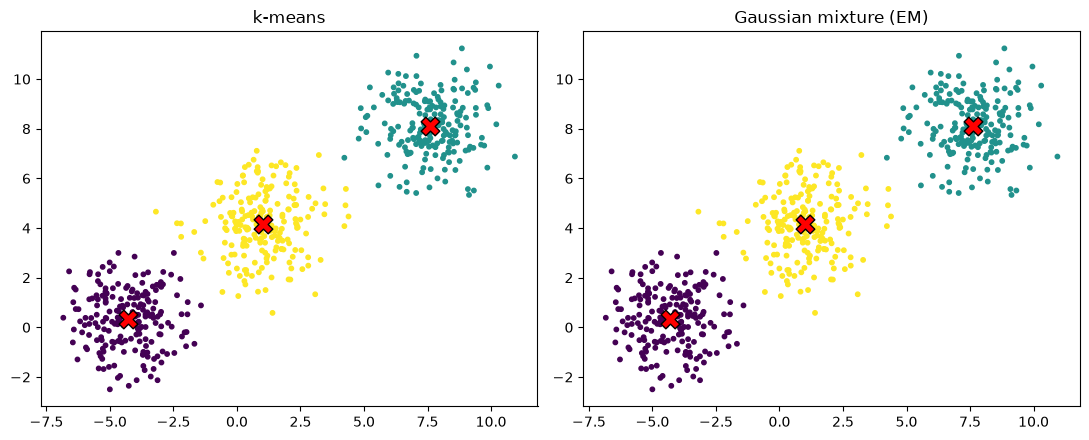

In [3]:
Xb, _ = make_blobs(n_samples=600, centers=3, cluster_std=1.2, random_state=3)
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xb)
gmm = GaussianMixtureEM(n_components=3, random_state=0).fit(Xb)
print(f"k-means inertia: {km.inertia_:.2f}")
print(f"GMM converged in {gmm.n_iter_} EM iterations, mean log-likelihood {gmm.score(Xb):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Xb[:, 0], Xb[:, 1], c=km.labels_, cmap="viridis", s=10)
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker="X", s=180, c="red", edgecolors="k")
axes[0].set_title("k-means")
axes[1].scatter(Xb[:, 0], Xb[:, 1], c=gmm.predict(Xb), cmap="viridis", s=10)
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker="X", s=180, c="red", edgecolors="k")
axes[1].set_title("Gaussian mixture (EM)")
plt.tight_layout()
plt.show()

## PCA on the digits dataset

Project the 64-dimensional digit images to 2D. The EM log-likelihood curve on the right shows the guaranteed monotone improvement of the GMM fit above.

explained variance ratio: [0.14890594 0.13618771]


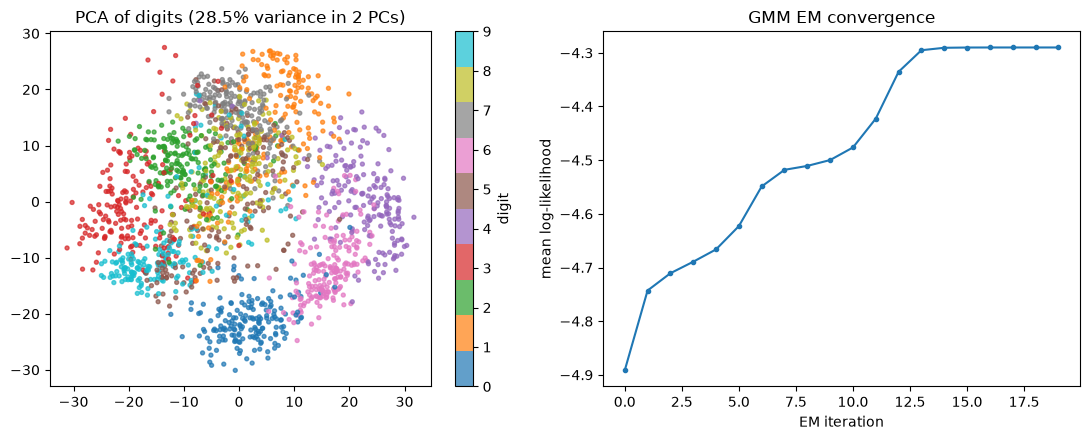

In [4]:
Xd, yd = load_digits(return_X_y=True)
pca = PCA(n_components=2)
Z = pca.fit_transform(Xd)
print(f"explained variance ratio: {pca.explained_variance_ratio_}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=yd, cmap="tab10", s=8, alpha=0.7)
fig.colorbar(sc, ax=axes[0], label="digit")
axes[0].set_title(f"PCA of digits ({pca.explained_variance_ratio_.sum():.1%} variance in 2 PCs)")
axes[1].plot(gmm.log_likelihood_history_, marker="o", markersize=3)
axes[1].set_xlabel("EM iteration")
axes[1].set_ylabel("mean log-likelihood")
axes[1].set_title("GMM EM convergence")
plt.tight_layout()
plt.show()